# pyshiro アノテーションガイド

このノートブックは、歌声音声ファイルに対して音素境界アノテーションを行う一連の手順をガイドします。

## 全体の流れ

```
raw_wav/          （任意のサンプリングレート）
    ↓  00_resample.py
wav_16k/          （16kHz モノラル）
    ↓  01_cut.py
cut_wav/          （フレーズ単位のセグメント）+ {stem}_cuts.json + lyrics/*.txt（空テンプレ）
    ↓  【手作業】歌詞テキストを記入
    ↓  02_align.py
labels/           （自動アライメント結果 .lab / .TextGrid）
    ↓  【手作業】Praat / Audacity / vlabeler で境界を修正
    ↓  03_merge.py
output/           （1 曲分の HTK .lab）
```

## 設定

ここだけ変更すれば以降のセルはそのまま実行できます。

In [2]:
import os
from pathlib import Path

# ノートブックの場所に関わらず、リポジトリルートを作業ディレクトリにする
_cwd = Path.cwd()
if _cwd.name == "workflow":
    os.chdir(_cwd.parent)
print(f"作業ディレクトリ: {Path.cwd()}")

# --- パス設定 ---
RAW_WAV_DIR  = Path("example/raw_wav")   # 変換前の音声（任意 SR）
WAV_16K_DIR  = Path("example/wav_16k")   # 16kHz 変換後
CUT_WAV_DIR  = Path("example/cut_wav")   # セグメント分割後
LYRICS_DIR   = Path("example/lyrics")    # 歌詞テキスト
LABELS_DIR   = Path("example/labels")    # 自動アライメント結果
OUTPUT_DIR   = Path("example/output")    # マージ済み最終ラベル

MODEL_PATH    = Path("checkpoint/pyshiro-jp-v1.hsmm")
PHONEMAP_PATH = Path("checkpoint/pyshiro-jp-v1_phonemap.json")

# --- カット設定 ---
MAX_DUR           = 15.0  # セグメント最大秒数
MIN_DUR           = 2.0   # これより短いセグメントは直前に結合
LONG_SILENCE      = 1.0   # 分割点とみなす無音長（秒）
MIN_SPLIT_SILENCE = 0.3   # max_dur 超過時に分割を許可する最小無音長（cl などで切れるのを防ぐ）

# --- 出力ラベル形式 ---
LABEL_FORMAT = "textgrid"  # "lab" / "textgrid" / "audacity"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("設定 OK")

作業ディレクトリ: /Users/air/Documents/python/pyshiro
設定 OK


---
## Step 0 : リサンプリング

`raw_wav/` 内の WAV を 16kHz モノラルに変換して `wav_16k/` に保存します。  
すでに 16kHz モノラルの場合はスキップしてください。

In [6]:
!python workflow/00_resample.py \
    --in_dir  {RAW_WAV_DIR} \
    --out_dir {WAV_16K_DIR}

2 ファイルを変換中 (16000 Hz モノラル) ...
  akai_kutsu.wav  96000 Hz mono → 16000 Hz  [97.1s]
  amehuri.wav  96000 Hz mono → 16000 Hz  [62.2s]

完了。出力先: example/wav_16k


---
## Step 1 : セグメント分割

エネルギーベースで無音区間を検出し、長いポーズを跨がないようにフレーズ単位で分割します。  
各セグメントの WAV と `{stem}_cuts.json`（オフセット記録）、および空の歌詞テンプレートを生成します。

In [2]:
!python workflow/01_cut.py \
    --wav_dir    {WAV_16K_DIR} \
    --out_dir    {CUT_WAV_DIR} \
    --lyrics_dir {LYRICS_DIR} \
    --max_dur    {MAX_DUR} \
    --min_dur    {MIN_DUR} \
    --long_silence {LONG_SILENCE}


akai_kutsu.wav  (97.1s, 16000 Hz)
  → 3 セグメント
  akai_kutsu_s001  5.58s – 27.87s  (22.3s)
  akai_kutsu_s002  33.54s – 56.50s  (23.0s)
  akai_kutsu_s003  62.03s – 85.05s  (23.0s)
  → akai_kutsu_cuts.json を保存しました

amehuri.wav  (62.2s, 16000 Hz)
  → 3 セグメント
  amehuri_s001  1.62s – 15.72s  (14.1s)
  amehuri_s002  17.74s – 31.82s  (14.1s)
  amehuri_s003  33.98s – 48.00s  (14.0s)
  → amehuri_cuts.json を保存しました

歌詞テンプレートを生成しました: example/lyrics
各 .txt ファイルにひらがなで歌詞を記入してから 02_align.py を実行してください。

完了。


### 生成されたセグメントを確認

In [8]:
import soundfile as sf

wavs = sorted(CUT_WAV_DIR.glob("*.wav"))
print(f"{len(wavs)} セグメント")
for p in wavs:
    info = sf.info(p)
    print(f"  {p.name:40s}  {info.duration:.1f}s")

6 セグメント
  akai_kutsu_s001.wav                       22.3s
  akai_kutsu_s002.wav                       23.0s
  akai_kutsu_s003.wav                       23.0s
  amehuri_s001.wav                          14.1s
  amehuri_s002.wav                          14.1s
  amehuri_s003.wav                          14.0s


---
## Step 2 : 歌詞を記入する【手作業】

`lyrics/` フォルダ内に各セグメントと同名の `.txt` が生成されています。  
それぞれのファイルにひらがなで歌詞を記入してください。

- 改行 → `pau`（ポーズ）
- `br` は行中に直接埋め込み可能（例: `brねがいわいちど`）
- ポーズのみの行: `pau`、息継ぎのみの行: `br`

例:
```
brねがいわいちどbrはなしたら
brくずれてく
brしゅんかんむかいかぜbrだれもしらないbrあしあとうぉ
br
```

次のセルで歌詞記入状況を確認できます。

In [9]:
txts = sorted(LYRICS_DIR.glob("*.txt"))
empty = [p for p in txts if p.stat().st_size == 0]
filled = [p for p in txts if p.stat().st_size > 0]
print(f"記入済み: {len(filled)} / {len(txts)}")
if empty:
    print("未記入:")
    for p in empty:
        print(f"  {p.name}")

記入済み: 6 / 6


---
## Step 3 : 自動アライメント

事前学習済みモデルを使って各セグメントの音素境界を自動推定します。  
歌詞が空のセグメントは自動的にスキップされます。

In [19]:
!python workflow/02_align.py \
    --wav_dir    {CUT_WAV_DIR} \
    --lyrics_dir {LYRICS_DIR} \
    --model      {MODEL_PATH} \
    --phonemap   {PHONEMAP_PATH} \
    --out_dir    {LABELS_DIR} \
    --format     {LABEL_FORMAT}

6 セグメントをアライメント中 (jobs=10) ...
amehuri_s001:   saved: amehuri_s001.TextGrid
amehuri_s002:   saved: amehuri_s002.TextGrid
amehuri_s003:   saved: amehuri_s003.TextGrid
akai_kutsu_s001:   saved: akai_kutsu_s001.TextGrid
akai_kutsu_s002:   saved: akai_kutsu_s002.TextGrid
akai_kutsu_s003:   saved: akai_kutsu_s003.TextGrid

完了。


### アライメント結果を可視化

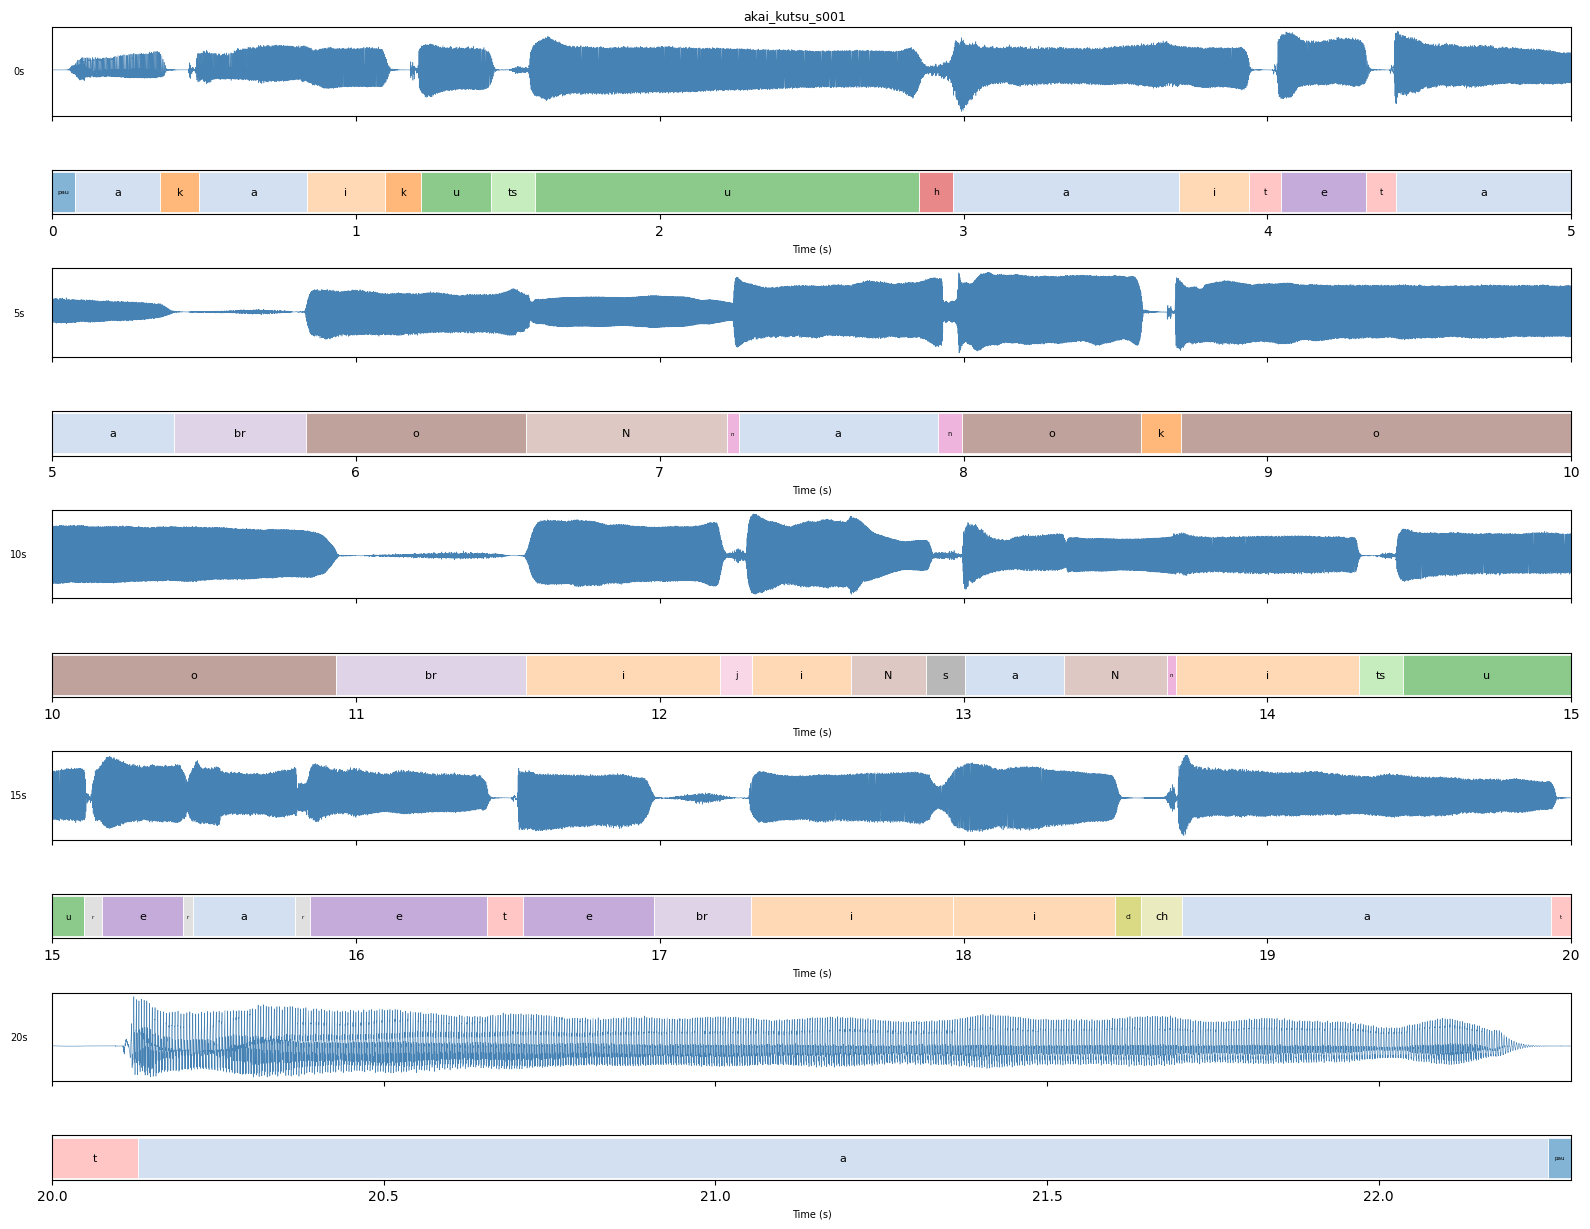

In [20]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

_PALETTE = plt.cm.tab20.colors
_COLORS = {}
def _ph_color(ph):
    if ph not in _COLORS:
        _COLORS[ph] = _PALETTE[len(_COLORS) % len(_PALETTE)]
    return _COLORS[ph]

def _read_lab(path):
    intervals = []
    for line in path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) >= 3:
            s, e = float(parts[0]), float(parts[1])
            if s > 1000:
                s, e = s * 1e-7, e * 1e-7
            intervals.append((s, e, parts[2]))
    return intervals

def _read_textgrid(path):
    import re
    text = path.read_text(encoding="utf-8")
    xmins = re.findall(r'xmin\s*=\s*([0-9.e+\-]+)', text)
    xmaxs = re.findall(r'xmax\s*=\s*([0-9.e+\-]+)', text)
    texts = re.findall(r'text\s*=\s*"([^"]*)"', text)
    n = len(texts)
    return [(float(xmins[2+i]), float(xmaxs[2+i]), texts[i]) for i in range(n)]

FIG_WIDTH    = 16   # 固定幅（インチ）
ROW_SPAN_SEC = 5.0  # 1行あたりの表示秒数

def visualize_segment(stem):
    wav_path = CUT_WAV_DIR / f"{stem}.wav"
    if LABEL_FORMAT == "textgrid":
        lab_path = LABELS_DIR / f"{stem}.TextGrid"
        intervals = _read_textgrid(lab_path) if lab_path.exists() else []
    else:
        lab_path = LABELS_DIR / f"{stem}.lab"
        intervals = _read_lab(lab_path) if lab_path.exists() else []

    wav, sr = sf.read(wav_path, dtype="float32")
    duration = len(wav) / sr

    import math
    n_rows = max(1, math.ceil(duration / ROW_SPAN_SEC))

    fig, axes = plt.subplots(
        n_rows * 2, 1,
        figsize=(FIG_WIDTH, n_rows * 2.5),
        gridspec_kw={"height_ratios": [2, 1] * n_rows},
    )
    if n_rows == 1:
        axes = list(axes)

    for row in range(n_rows):
        t0 = row * ROW_SPAN_SEC
        t1 = min(t0 + ROW_SPAN_SEC, duration)
        ax_wav = axes[row * 2]
        ax_lab = axes[row * 2 + 1]

        # 波形
        s0 = int(t0 * sr)
        s1 = int(t1 * sr)
        chunk = wav[s0:s1]
        ax_wav.plot(np.linspace(t0, t1, len(chunk)), chunk,
                    color="steelblue", linewidth=0.4, rasterized=True)
        ax_wav.set_xlim(t0, t1)
        ax_wav.set_yticks([])
        ax_wav.tick_params(labelbottom=False)
        ax_wav.set_ylabel(f"{t0:.0f}s", fontsize=7, rotation=0, labelpad=24, va="center")

        # ラベル
        ax_lab.set_xlim(t0, t1)
        ax_lab.set_ylim(0, 1)
        ax_lab.set_yticks([])
        seen = set()
        for s, e, ph in intervals:
            if e <= t0 or s >= t1:
                continue
            sc, ec = max(s, t0), min(e, t1)
            c = _ph_color(ph)
            ax_lab.add_patch(mpatches.FancyBboxPatch(
                (sc, 0.05), ec - sc, 0.9, boxstyle="square,pad=0",
                facecolor=(*c[:3], 0.55), edgecolor="white", linewidth=0.5))
            mid = (sc + ec) / 2
            ax_lab.text(mid, 0.5, ph, ha="center", va="center",
                        fontsize=max(4, min(8, (ec - sc) * 60)),
                        color="black", clip_on=True)
            for t in (sc, ec):
                if t not in seen:
                    ax_lab.axvline(t, color="white", linewidth=0.4, alpha=0.7)
                    seen.add(t)
        ax_lab.set_xlabel("Time (s)", fontsize=7)

    fig.suptitle(stem, fontsize=9)
    fig.tight_layout()
    plt.show()

# 最初のセグメントを表示
label_files = sorted(LABELS_DIR.glob("*"))
if label_files:
    visualize_segment(label_files[0].stem)
else:
    print("ラベルファイルがありません。")

---
## Step 5 : 1 曲分に結合

ここへ進む前に、自動生成されたラベルを手動で修正してください。手修正済みのセグメントラベルを `{stem}_cuts.json` のオフセット情報を使って結合します。  
オフセット適用はサンプル単位の整数演算なので、浮動小数点誤差は生じません。

In [3]:
import json

cuts_files = sorted(CUT_WAV_DIR.glob("*_cuts.json"))
print(f"{len(cuts_files)} 曲分の cuts.json が見つかりました:")
for p in cuts_files:
    cuts = json.loads(p.read_text())
    print(f"  {p.name}  ({len(cuts)} セグメント)")

2 曲分の cuts.json が見つかりました:
  akai_kutsu_cuts.json  (3 セグメント)
  amehuri_cuts.json  (3 セグメント)


In [4]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --out_format で出力形式を指定できます（省略時は --format と同じ）
#   lab      : HTK 100ns 整数（ENUNU / NNSVS 標準）← デフォルト
#   textgrid : Praat TextGrid（秒単位）
#   audacity : Audacity ラベル（秒・タブ区切り）
OUT_FORMAT = "lab"

for cuts_path in cuts_files:
    stem = cuts_path.stem.replace("_cuts", "")
    _EXT = {"lab": ".lab", "textgrid": ".TextGrid", "audacity": ".txt"}
    out_path = OUTPUT_DIR / f"{stem}{_EXT[OUT_FORMAT]}"
    print(f"\n{stem}")
    !python workflow/03_merge.py \
        --cuts       {cuts_path} \
        --lab_dir    {LABELS_DIR} \
        --out        {out_path} \
        --format     {LABEL_FORMAT} \
        --out_format {OUT_FORMAT}


akai_kutsu
  akai_kutsu_s001: 54 intervals, offset=55800000 HTK (89280 samples)
  akai_kutsu_s002: 64 intervals, offset=335400000 HTK (536640 samples)
  akai_kutsu_s003: 54 intervals, offset=620300000 HTK (992480 samples)

170 intervals, 総時間 97.11s → example/output/akai_kutsu.lab (lab)

amehuri
  amehuri_s001: 78 intervals, offset=16200000 HTK (25920 samples)
  amehuri_s002: 81 intervals, offset=177400000 HTK (283840 samples)
  amehuri_s003: 81 intervals, offset=339800000 HTK (543680 samples)

238 intervals, 総時間 62.23s → example/output/amehuri.lab (lab)


### マージ結果を確認

In [6]:
for lab_path in sorted(OUTPUT_DIR.glob("*.lab")):
    lines = lab_path.read_text(encoding="utf-8").splitlines()
    first, last = lines[0], lines[-1]
    total_sec = int(last.split()[1]) * 1e-7
    print(f"{lab_path.name}  {len(lines)} intervals  総時間: {total_sec:.2f}s")
    print(f"  先頭: {first}")
    print(f"  末尾: {last}")

akai_kutsu.lab  170 intervals  総時間: 97.11s
  先頭: 0 56550000 pau
  末尾: 849850000 971131250 pau
amehuri.lab  238 intervals  総時間: 62.23s
  先頭: 0 21800000 pau
  末尾: 479550000 622321875 pau
